# LoRA (Low-Rank Adaptation)


Fine-tuning large language models is a resource intensive process. LoRA is a technique that allows us to fine-tune large language models with a small number of parameters. It works by adding and optimizing smaller matrices to the attention weights, typically reducing trainable parameters by about 90%.



## 1. Understanding LoRA


LoRA (Low-Rank Adaptation) is a parameter-efficient fine-tuning technique that freezes the pre-trained model weights and injects trainable rank decomposition matrices into the model’s layers. Instead of training all model parameters during fine-tuning, LoRA decomposes the weight updates into smaller matrices through low-rank decomposition, significantly reducing the number of trainable parameters while maintaining model performance. For example, when applied to GPT-3 175B, LoRA reduced trainable parameters by 10,000x and GPU memory requirements by 3x compared to full fine-tuning. 

LoRA works by adding pairs of rank decomposition matrices to transformer layers, typically focusing on attention weights. During inference, these adapter weights can be merged with the base model, resulting in no additional latency overhead. LoRA is particularly useful for adapting large language models to specific tasks or domains while keeping resource requirements manageable.



## 2. Key advantages of LoRA

### 2.1. Memory Efficiency

* Only adapter parameters are stored in GPU memory

* Base model weights remain frozen and can be loaded in lower precision

* Enables fine-tuning of large models on consumer GPUs

### 2.2. Training Features:

* Native PEFT/LoRA integration with minimal setup

* Support for QLoRA (Quantized LoRA) for even better memory efficiency

### 2.3. Adapter Management:

* Adapter weight saving during checkpoints

* Features to merge adapters back into base model

## 3. Loading LoRA Adapters with PEFT


PEFT is a library that provides a unified interface for loading and managing PEFT methods, including LoRA. It allows you to easily load and switch between different PEFT methods, making it easier to experiment with different fine-tuning techniques.



Adapters can be loaded onto a pretrained model with `load_adapter()`, which is useful for trying out different adapters whose weights aren’t merged. Set the active adapter weights with the `set_adapter()` function. To return the base model, you could use `unload()` to unload all of the LoRA modules. This makes it easy to switch between different task-specific weights.



In [6]:
from peft import PeftModel, PeftConfig
from transformers import AutoModelForCausalLM

peft_model_id = "ybelkada/opt-350m-lora"

# Load the base model declared by the adapter config instead of pointing to the adapter repo itself
config = PeftConfig.from_pretrained(peft_model_id)
base_model = AutoModelForCausalLM.from_pretrained(
    config.base_model_name_or_path,
    use_safetensors=True,  # avoid torch.load vulnerability requirement
)
lora_model = PeftModel.from_pretrained(base_model, peft_model_id)


model.safetensors:   0%|          | 0.00/662M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/6.30M [00:00<?, ?B/s]

## 4. Fine-tune LLM using trl and the SFTTrainer with LoRA


The `SFTTrainer` from `trl` provides integration with LoRA adapters through the PEFT library. This means that we can fine-tune a model in the same way as we did with SFT, but use LoRA to reduce the number of parameters we need to train.



We’ll use the `LoRAConfig` class from PEFT in our example. The setup requires just a few configuration steps:

1. Define the LoRA configuration (rank, alpha, dropout)

2. Create the SFTTrainer with PEFT config

3. Train and save the adapter weights

In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model_name = "HuggingFaceTB/SmolLM2-135M-Instruct"

model = AutoModelForCausalLM.from_pretrained(model_name)
model.to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name)

finetune_name = "SmolLM2-FT-MyDataset"


Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

## 5. LoRA Configuration


Let’s walk through the LoRA configuration and key parameters.



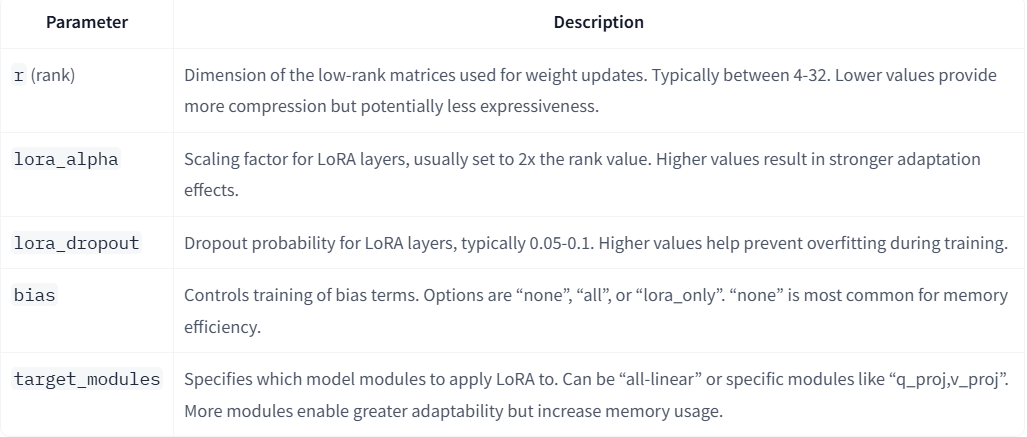

When implementing PEFT methods, start with small rank values (4-8) for LoRA and monitor training loss. Use validation sets to prevent overfitting and compare results with full fine-tuning baselines when possible. The effectiveness of different methods can vary by task, so experimentation is key.



## 6. Using TRL with PEFT


### Pre-setup steps

First, we will implement some pre-setup steps for our task.

In [ ]:
from datasets import load_dataset

dataset = load_dataset(path="HuggingFaceTB/smoltalk", name="everyday-conversations")
dataset

PEFT methods can be combined with TRL for fine-tuning to reduce memory requirements. We can pass the `LoraConfig` to the model when loading it.



In [7]:
from peft import LoraConfig, TaskType

rank_dimension = 4
lora_alpha = 8
lora_dropout = 0.05

peft_config = LoraConfig(
    r=rank_dimension,
    lora_alpha=lora_alpha,
    lora_dropout=lora_dropout,
    bias="none",
    target_modules="all-linear",   # Which modules to apply LoRA to
    task_type=TaskType.CAUSAL_LM
)

Before we can start our training we need to define the hyperparameters `TrainingArguments` we want to use.

In [ ]:
from trl import SFTConfig, SFTTrainer

max_seq_length = 512  # max sequence length for model and packing of the dataset

args = SFTConfig(
    output_dir=finetune_name,
    max_length=max_seq_length,
    packing=True,
    num_train_epochs=1,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=2,
    gradient_checkpointing=True,
    optim="adamw_torch_fused",
    learning_rate=2e-4,
    max_grad_norm=0.3,
    warmup_ratio=0.03,
    lr_scheduler_type='constant',
    logging_steps=10,
    save_strategy="epoch",
    bf16=True,
    push_to_hub=False,
    report_to="none",
    dataset_kwargs={
        "add_special_tokens": False,
        "append_concat_token": False,
    }
)

TypeError: SFTConfig.__init__() got an unexpected keyword argument 'max_seq_length'

We will also need to define the `SFTTrainer` with the LoRA configuration.



In [ ]:
trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=dataset["train"],
    peft_config=peft_config,
    processing_class=tokenizer
)

Start training our model by calling the `train()` method on our `Trainer` instance. This will start the training loop and train our model. Since we are using a PEFT method, we will only save the adapted model weights and not the full model.

In [ ]:
trainer.train()
trainer.save_model()

## 7. Merge LoRA Adapter into the Original Model

When using LoRA, we only train adapter weights while keeping the base model frozen. During training, we save only these lightweight adapter weights (~2-10MB) rather than a full model copy. However, for deployment, you might want to merge the adapters back into the base model for:

1. **Simplified Deployment**: Single model file instead of base model + adapters

2. **Inference Speed**: No adapter computation overhead

3. **Framework Compatibility**: Better compatibility with serving frameworks


In [8]:
from peft import AutoPeftModelForCausalLM

model = AutoPeftModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=args.output_dir,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
)

merged_model = model.merge_and_unload()
merged_model.save_pretrained(
    args.output_dir, 
    safe_serialization=True,  # save in .safetensors format
    max_shard_size='2GB'      # chunking model in 2GB chunk each if the model is too large
)

NameError: name 'args' is not defined